Singular Value Decomposition (SVD) for Collaborative Filtering

In [6]:
import os
import urllib.request
import zipfile


BASE_DIR = "/content/"
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# MovieLens 20M dataset
MOVIELENS_URL = "https://files.grouplens.org/datasets/movielens/ml-20m.zip"
ZIP_PATH = os.path.join(RAW_DIR, "ml-20m.zip")
EXTRACT_DIR = os.path.join(RAW_DIR, "ml-20m")

# Download dataset
if not os.path.exists(ZIP_PATH):
    print("Downloading MovieLens 20M dataset...")
    urllib.request.urlretrieve(MOVIELENS_URL, ZIP_PATH)
    print("Download complete.")

# Extract dataset
if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(RAW_DIR)
    print("Extraction complete.")

# Example file paths
RATINGS_FILE = os.path.join(EXTRACT_DIR, "ratings.csv")
MOVIES_FILE = os.path.join(EXTRACT_DIR, "movies.csv")
TAGS_FILE = os.path.join(EXTRACT_DIR, "tags.csv")

print("Dataset ready:")
print(RATINGS_FILE)
print(MOVIES_FILE)
print(TAGS_FILE)

Download complete.
Extracting dataset...
Extraction complete.
Dataset ready:
/content/data/raw/ml-20m/ratings.csv
/content/data/raw/ml-20m/movies.csv
/content/data/raw/ml-20m/tags.csv


In [ ]:
# Load ratings matrix from preprocessed dataset

with open("out/preprocessing_results_part1.pkl", "rb") as f:
    data = pickle.load(f)

# Retrieve the sampled ratings data
sample = data["sample"]

print("Sample loaded")
print("Users:", sample["userId"].nunique())
print("Items:", sample["movieId"].nunique())
print("Ratings:", len(sample))

# Create user-item matrix rows = users, columns = items
R = sample.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

print("Ratings matrix R created")
print("Shape of R (users × items):", R.shape)

# Replace missing ratings with 0 standard for SVD baseline
R_matrix = R.fillna(0).values

print("Converted R to NumPy array")
print("R_matrix shape:", R_matrix.shape)


Sample loaded
Users: 10000
Items: 16979
Ratings: 1454360
Ratings matrix R created
Shape of R (users × items): (10000, 16979)
Converted R to NumPy array
R_matrix shape: (10000, 16979)


In [ ]:
# Calculate the average rating for each item r_i from the ratings matrix

# Average rating per item ignoring missing values
rbar_i_part2 = R.mean(axis=0)

print("Average rating per item computed")
print(rbar_i_part2.head())
print("Total items:", rbar_i_part2.shape[0])

# Save average item ratings

rbar_i_part2.to_csv("out/part2_rbar_i.csv", header=["rbar_i"])

print("Average item ratings saved to out/part2_rbar_i.csv")



Average rating per item computed
movieId
1    3.935017
2    3.238291
3    3.195190
4    2.859296
5    3.075548
dtype: float64
Total items: 16979
Average item ratings saved to out/part2_rbar_i.csv


In [ ]:
# Apply mean-filling replace missing ratings with each item's average rating

# Mean-fill missing values using item averages
R_mean_filled = R.copy()

for item in R_mean_filled.columns:
    R_mean_filled[item] = R_mean_filled[item].fillna(rbar_i_part2[item])

print("Mean-filling applied using item average ratings")
print("Any missing values left:", R_mean_filled.isna().sum().sum())

#Convert mean-filled matrix to NumPy array for SVD

R_mean_filled_matrix = R_mean_filled.values

print("Converted mean-filled ratings matrix to NumPy array")
print("Shape:", R_mean_filled_matrix.shape)


Mean-filling applied using item average ratings
Any missing values left: 0
Converted mean-filled ratings matrix to NumPy array
Shape: (10000, 16979)


In [ ]:
# Verify matrix completeness no missing values

missing_count = R_mean_filled.isna().sum().sum()

print("Total missing values in R_mean_filled:", missing_count)

if missing_count == 0:
    print("Matrix is complete: no missing values.")
else:
    print("Matrix is not complete: missing values still exist.")


Total missing values in R_mean_filled: 0
Matrix is complete: no missing values.


In [ ]:
# Full SVD Decomposition: R = U Σ Vᵀ

R_mat = R_mean_filled_matrix.astype(np.float64)

# Economy SVD
U, s, VT = np.linalg.svd(R_mat, full_matrices=False)

# Sigma as diagonal matrix (r x r)
Sigma = np.diag(s)

print("Economy SVD computed")
print("R shape     :", R_mat.shape)
print("U shape     :", U.shape)
print("Sigma shape :", Sigma.shape)
print("VT shape    :", VT.shape)

R_recon = U @ Sigma @ VT

# Mean absolute error
mae = np.mean(np.abs(R_recon - R_mat))
print("Reconstruction MAE:", mae)


# Save full SVD results

np.save("out/fullSVD_U.npy", U)
np.save("out/fullSVD_singular_values.npy", s)
np.save("out/fullSVD_VT.npy", VT)

print("Saved:")
print("- out/fullSVD_U.npy")
print("- out/fullSVD_singular_values.npy")
print("- out/fullSVD_VT.npy")


Economy SVD computed
R shape     : (10000, 16979)
U shape     : (10000, 10000)
Sigma shape : (10000, 10000)
VT shape    : (10000, 16979)
Reconstruction MAE: 2.1628110218873202e-14
Saved:
- out/fullSVD_U.npy
- out/fullSVD_singular_values.npy
- out/fullSVD_VT.npy


In [ ]:
# Build and save eigenpairs from SVD results

V = VT.T
eigenvalues = s**2

print("Shapes:")
print("R_mat:", R_mat.shape)
print("U    :", U.shape)
print("s    :", s.shape)
print("V    :", V.shape)

# Save all eigenvalues and V
np.save("out/eigenvalues_lambda.npy", eigenvalues)
np.save("out/V_matrix.npy", V)

print("Saved:")
print("out/eigenvalues_lambda.npy   (λ_i = σ_i^2)")
print("out/V_matrix.npy             (columns are v_i)")

# Save all singular values and build Sigma / X

Sigma = np.diag(s)

np.save("out/singular_values_sigma.npy", s)
np.save("out/Sigma_matrix.npy", Sigma)

print("Saved:")
print("out/singular_values_sigma.npy   (σ1..σr)")
print("out/Sigma_matrix.npy            (Σ / X)")


Shapes:
R_mat: (10000, 16979)
U    : (10000, 10000)
s    : (10000,)
V    : (16979, 10000)
Saved:
out/eigenvalues_lambda.npy   (λ_i = σ_i^2)
out/V_matrix.npy             (columns are v_i)
Saved:
out/singular_values_sigma.npy   (σ1..σr)
out/Sigma_matrix.npy            (Σ / X)


In [ ]:
# Verify Normalize v_i and save V^T

# Orthonormal check
VtV = VT @ V
max_offdiag = np.max(np.abs(VtV - np.eye(VtV.shape[0])))

print("Max |V^T V - I| =", max_offdiag)

# Save VT
np.save("out/VT_matrix.npy", VT)
print("Saved: out/VT_matrix.npy")

# Compute u_i and save U_computed

U_computed = np.zeros((R_mat.shape[0], V.shape[1]), dtype=np.float64)

for j in range(V.shape[1]):
    sigma = s[j]
    if sigma > 1e-12:
        U_computed[:, j] = (R_mat @ V[:, j]) / sigma
    else:
        U_computed[:, j] = 0.0

# compare to SVD U sign flips are normal in SVD
corr = []
for j in range(U.shape[1]):
    a = U[:, j]
    b = U_computed[:, j]
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na > 0 and nb > 0:
        corr.append(abs(np.dot(a, b) / (na * nb)))
    else:
        corr.append(0.0)

print("Mean |corr(U, U_computed)|:", float(np.mean(corr)))

np.save("out/U_computed_from_formula.npy", U_computed)
print("Saved: out/U_computed_from_formula.npy")

# Save eigenpairs as a compact structure for later use

eigenpairs = {
    "lambda": eigenvalues,
    "V": V
}

np.save("out/eigenpairs_lambda_V.npy", eigenpairs, allow_pickle=True)
print("Saved: out/eigenpairs_lambda_V.npy")



Max |V^T V - I| = 1.2851698871774175e-14
Saved: out/VT_matrix.npy
Mean |corr(U, U_computed)|: 0.8727234210066305
Saved: out/U_computed_from_formula.npy
Saved: out/eigenpairs_lambda_V.npy


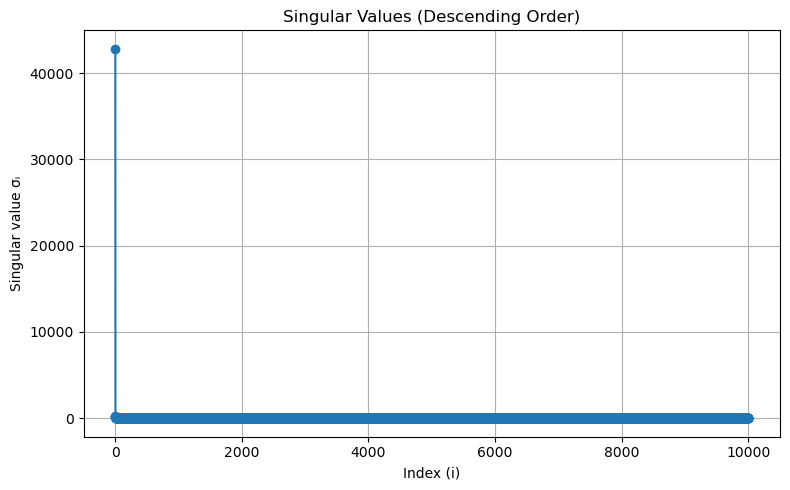

Saved: out/singular_values_descending.png


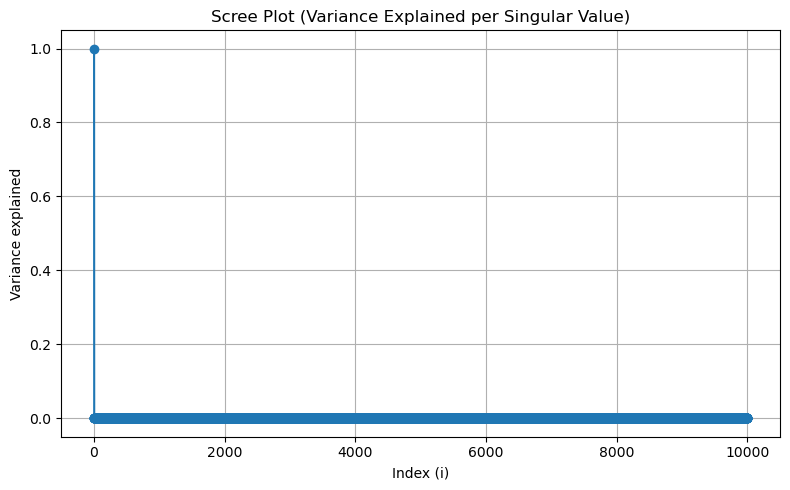

Saved: out/scree_plot_variance_explained.png


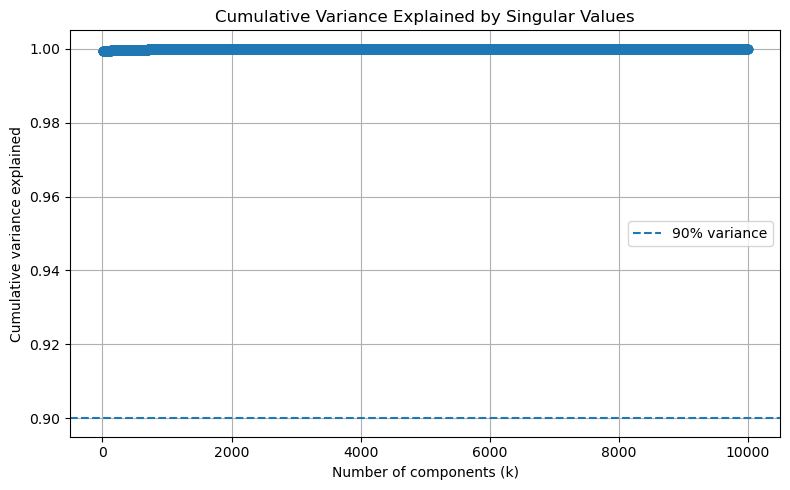

Saved: out/cumulative_variance_explained.png


In [ ]:
# Plot singular values in descending order

singular_values = s.copy()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(singular_values) + 1), singular_values, marker="o")
plt.xlabel("Index (i)")
plt.ylabel("Singular value σᵢ")
plt.title("Singular Values (Descending Order)")
plt.grid(True)
plt.tight_layout()

plt.savefig("out/singular_values_descending.png")
plt.show()

print("Saved: out/singular_values_descending.png")


# Variance explained by each singular value
variance_explained = (singular_values ** 2) / np.sum(singular_values ** 2)

# Cumulative variance
cumulative_variance = np.cumsum(variance_explained)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(variance_explained) + 1),
    variance_explained,
    marker="o",
    label="Individual variance"
)
plt.xlabel("Index (i)")
plt.ylabel("Variance explained")
plt.title("Scree Plot (Variance Explained per Singular Value)")
plt.grid(True)
plt.tight_layout()

plt.savefig("out/scree_plot_variance_explained.png")
plt.show()

print("Saved: out/scree_plot_variance_explained.png")

# Cumulative variance scree plot

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.xlabel("Number of components (k)")
plt.ylabel("Cumulative variance explained")
plt.title("Cumulative Variance Explained by Singular Values")
plt.axhline(0.9, linestyle="--", label="90% variance")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("out/cumulative_variance_explained.png")
plt.show()

print("Saved: out/cumulative_variance_explained.png")




In [ ]:
#  Truncated SVD Low-Rank Approximation for k = 5, 20, 50, 100

k_values = [5, 20, 50, 100]

# store reconstructed low-rank matrices
R_approx = {}

# store reconstruction errors (MAE, RMSE)
errors = {}

for k in k_values:
    k = min(k, len(s))

    U_k = U[:, :k]
    s_k = s[:k]
    VT_k = VT[:k, :]

    Sigma_k = np.diag(s_k)

    # Low-rank approximation
    R_k = U_k @ Sigma_k @ VT_k
    R_approx[k] = R_k

    # Reconstruction errors vs mean-filled matrix
    diff = R_k - R_mat
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))

    errors[k] = {"MAE": mae, "RMSE": rmse}

    print(f"k={k}: MAE={mae:.6f}, RMSE={rmse:.6f}")

# Save truncated SVD components and errors

for k in k_values:
    k = min(k, len(s))
    np.save(f"out/truncSVD_U_k{k}.npy", U[:, :k])
    np.save(f"out/truncSVD_s_k{k}.npy", s[:k])
    np.save(f"out/truncSVD_VT_k{k}.npy", VT[:k, :])

print("Saved truncated SVD components for k = 5, 20, 50, 100 in out/")

# Save errors table
errors_df = pd.DataFrame(errors).T
errors_df.index.name = "k"
errors_df.to_csv("out/truncatedSVD_reconstruction_errors.csv")

print("Saved: out/truncatedSVD_reconstruction_errors.csv")



k=5: MAE=0.009713, RMSE=0.082861
k=20: MAE=0.010877, RMSE=0.079970
k=50: MAE=0.011746, RMSE=0.076561
k=100: MAE=0.012513, RMSE=0.072325
Saved truncated SVD components for k = 5, 20, 50, 100 in out/
Saved: out/truncatedSVD_reconstruction_errors.csv


In [ ]:
# Reload SVD components from disk
U  = np.load("out/fullSVD_U.npy")
s  = np.load("out/fullSVD_singular_values.npy")
VT = np.load("out/fullSVD_VT.npy")

print("Reloaded SVD components:")
print("U shape :", U.shape)
print("s shape :", s.shape)
print("VT shape:", VT.shape)


Reloaded SVD components:
U shape : (10000, 10000)
s shape : (10000,)
VT shape: (10000, 16979)


In [ ]:
# For each k: build U_k, X_k Sigma_k, V_k and compute R_k

k_values = [5, 20, 50, 100]

# Full X (Sigma) if you built it earlier; otherwise this makes it:
X = np.diag(s)

results_3_2 = {}

for k in k_values:
    k = min(k, len(s))

    # U_k: first k columns of U
    U_k = U[:, :k]

    # X_k: top-left k x k
    X_k = X[:k, :k]

    # V_k: first k columns of V
    V = VT.T
    V_k = V[:, :k]

    # Approximation R_k
    R_k = U_k @ X_k @ V_k.T

    results_3_2[k] = {
        "U_k": U_k,
        "X_k": X_k,
        "V_k": V_k,
        "R_k": R_k
    }

    print(f"k={k} -> U_k:{U_k.shape}, X_k:{X_k.shape}, V_k:{V_k.shape}, R_k:{R_k.shape}")


#  Save U_k, X_k, V_k for each k

for k in results_3_2:
    np.save(f"out/3_2_U_k{k}.npy", results_3_2[k]["U_k"])
    np.save(f"out/3_2_X_k{k}.npy", results_3_2[k]["X_k"])
    np.save(f"out/3_2_V_k{k}.npy", results_3_2[k]["V_k"])

print("Saved U_k, X_k, V_k for k = 5, 20, 50, 100 in out/")


k=5 -> U_k:(10000, 5), X_k:(5, 5), V_k:(16979, 5), R_k:(10000, 16979)
k=20 -> U_k:(10000, 20), X_k:(20, 20), V_k:(16979, 20), R_k:(10000, 16979)
k=50 -> U_k:(10000, 50), X_k:(50, 50), V_k:(16979, 50), R_k:(10000, 16979)
k=100 -> U_k:(10000, 100), X_k:(100, 100), V_k:(16979, 100), R_k:(10000, 16979)
Saved U_k, X_k, V_k for k = 5, 20, 50, 100 in out/


In [ ]:
import pickle
import numpy as np
import pandas as pd

# Reload preprocessing data
with open("out/preprocessing_results_part1.pkl", "rb") as f:
    data = pickle.load(f)

sample = data["sample"]
rbar_i = data["rbar_i"]

# Rebuild R
R = sample.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

# vectorized mean-filling
R_mean_filled = R.fillna(rbar_i)

R_mean_filled_matrix = R_mean_filled.values.astype(np.float64)

print("R_mean_filled_matrix")
print("Shape:", R_mean_filled_matrix.shape)
print("Missing values:", np.isnan(R_mean_filled_matrix).sum())


Recovered R_mean_filled_matrix FAST
Shape: (10000, 16979)
Missing values: 0


In [ ]:
# Reconstruction error MAE, RMSE for each k

R_mat = R_mean_filled_matrix.astype(np.float64)

k_values = [5, 20, 50, 100]

rows = []
for k in k_values:
    k = min(k, len(s))

    U_k = U[:, :k]
    Sigma_k = np.diag(s[:k])
    VT_k = VT[:k, :]

    R_k = U_k @ Sigma_k @ VT_k

    diff = R_k - R_mat
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))

    rows.append([k, mae, rmse])
    print(f"k={k}: MAE={mae:.6f}, RMSE={rmse:.6f}")

errors_df = pd.DataFrame(rows, columns=["k", "MAE_all_entries", "RMSE_all_entries"])
errors_df.to_csv("out/reconstruction_errors_all_entries.csv", index=False)

print("Saved: out/reconstruction_errors_all_entries.csv")

# Recommended for CF MAE/RMSE on ONLY observed ratings non-missing in original R

mask_observed = ~np.isnan(R.values)
R_true = R.values[mask_observed].astype(np.float64)

rows_obs = []
for k in k_values:
    k = min(k, len(s))

    R_k = (U[:, :k] @ np.diag(s[:k]) @ VT[:k, :])
    R_pred = R_k[mask_observed]

    diff = R_pred - R_true
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))

    rows_obs.append([k, mae, rmse])
    print(f"[Observed] k={k}: MAE={mae:.6f}, RMSE={rmse:.6f}")

errors_obs_df = pd.DataFrame(rows_obs, columns=["k", "MAE_observed", "RMSE_observed"])
errors_obs_df.to_csv("out/reconstruction_errors_observed_only.csv", index=False)

print("Saved: out/reconstruction_errors_observed_only.csv")



k=5: MAE=0.009713, RMSE=0.082861
k=20: MAE=0.010877, RMSE=0.079970
k=50: MAE=0.011746, RMSE=0.076561
k=100: MAE=0.012513, RMSE=0.072325
Saved: out/reconstruction_errors_all_entries.csv
[Observed] k=5: MAE=0.680360, RMSE=0.879360
[Observed] k=20: MAE=0.643729, RMSE=0.838077
[Observed] k=50: MAE=0.601574, RMSE=0.792543
[Observed] k=100: MAE=0.548941, RMSE=0.736752
Saved: out/reconstruction_errors_observed_only.csv


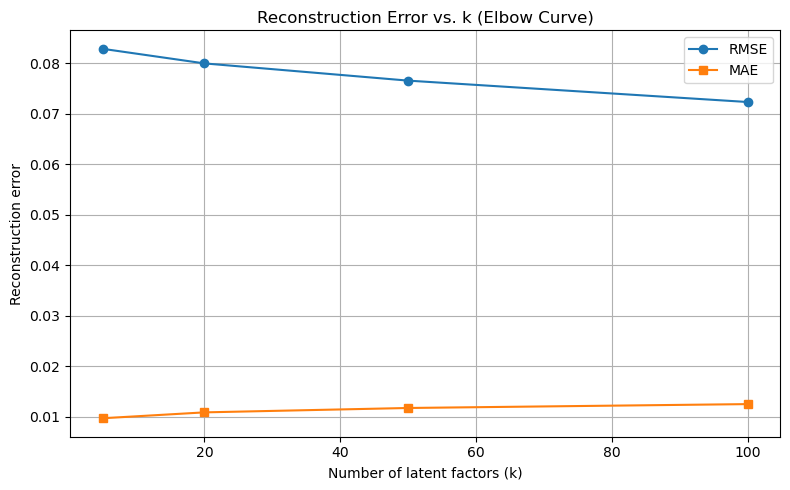

In [ ]:
# Load reconstruction errors
errors_df = pd.read_csv("out/reconstruction_errors_all_entries.csv")

plt.figure(figsize=(8, 5))
plt.plot(errors_df["k"], errors_df["RMSE_all_entries"], marker="o", label="RMSE")
plt.plot(errors_df["k"], errors_df["MAE_all_entries"], marker="s", label="MAE")

plt.xlabel("Number of latent factors (k)")
plt.ylabel("Reconstruction error")
plt.title("Reconstruction Error vs. k (Elbow Curve)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("out/elbow_curve_reconstruction_error.png")
plt.show()


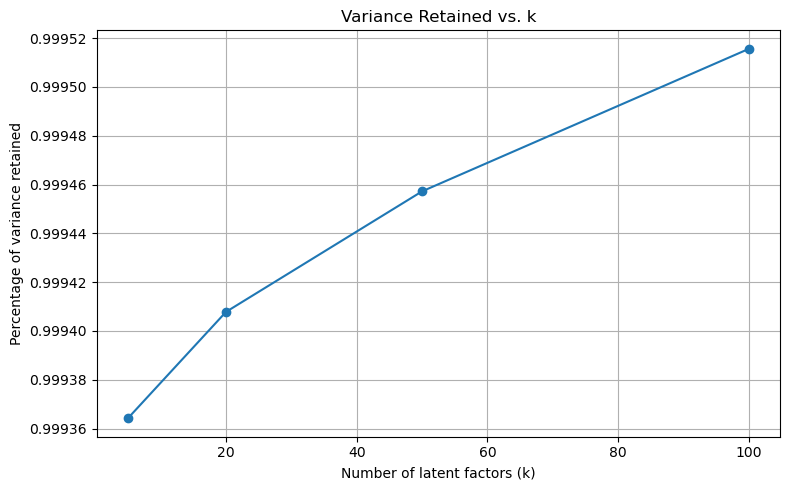

In [ ]:
# k values used
k_values = errors_df["k"].values

# Total variance
total_variance = np.sum(s**2)

variance_retained = []
for k in k_values:
    variance_k = np.sum(s[:k]**2) / total_variance
    variance_retained.append(variance_k)

variance_df = pd.DataFrame({
    "k": k_values,
    "variance_retained": variance_retained
})

plt.figure(figsize=(8, 5))
plt.plot(variance_df["k"], variance_df["variance_retained"], marker="o")
plt.xlabel("Number of latent factors (k)")
plt.ylabel("Percentage of variance retained")
plt.title("Variance Retained vs. k")
plt.grid(True)
plt.tight_layout()

plt.savefig("out/variance_retained_vs_k.png")
plt.show()


In [ ]:
# Compute first-order differences in RMSE (elbow heuristic)
rmse_diff = errors_df["RMSE_all_entries"].diff().abs()

elbow_df = pd.DataFrame({
    "k": errors_df["k"],
    "RMSE": errors_df["RMSE_all_entries"],
    "RMSE_change": rmse_diff
})

print(elbow_df)


     k      RMSE  RMSE_change
0    5  0.082861          NaN
1   20  0.079970     0.002891
2   50  0.076561     0.003409
3  100  0.072325     0.004237


In [ ]:
# Load everything needed for Part 4 sample , targets , SVD

# Load Part 1 saved results
with open("out/preprocessing_results_part1.pkl", "rb") as f:
    data = pickle.load(f)

sample = data["sample"][["userId", "movieId", "rating"]].copy()

# Load full SVD components economy
U  = np.load("out/fullSVD_U.npy")
s  = np.load("out/fullSVD_singular_values.npy")
VT = np.load("out/fullSVD_VT.npy")
V = VT.T

print("Loaded:")
print("sample rows:", len(sample))
print("U:", U.shape, "s:", s.shape, "VT:", VT.shape)

# Target users/items

U1 = data.get("U1", data.get("cold_user"))
U2 = data.get("U2", data.get("medium_user"))
U3 = data.get("U3", data.get("rich_user"))
I1 = data.get("I1")
I2 = data.get("I2")

print("Targets:")
print("U1,U2,U3:", U1, U2, U3)
print("I1,I2:", I1, I2)


Loaded:
sample rows: 1454360
U: (10000, 10000) s: (10000,) VT: (10000, 16979)
Targets:
U1,U2,U3: 1 131 4222
I1,I2: 5837 72505


In [ ]:
# Set the optimal k values from elbow analysis


optimal_k_values = [50]


In [ ]:
# Build user/item index mapping consistent with the SVD ordering

users = np.sort(sample["userId"].unique())
items = np.sort(sample["movieId"].unique())

user_to_idx = {uid: idx for idx, uid in enumerate(users)}
item_to_idx = {iid: idx for idx, iid in enumerate(items)}

# Quick sanity check indices should be within U/V shapes
print("n_users:", len(users), "n_items:", len(items))
print("U rows:", U.shape[0], "V rows:", V.shape[0])


n_users: 10000 n_items: 16979
U rows: 10000 V rows: 16979


In [ ]:
# Predict missing ratings for target items (I1, I2) for each target user (U1,U2,U3)

def predict_rating_trunc_svd(uid, iid, k):
    # Map ids to indices
    if uid not in user_to_idx or iid not in item_to_idx:
        return np.nan
    u_idx = user_to_idx[uid]
    i_idx = item_to_idx[iid]
    k = min(k, len(s))

    # Efficient dot
    return float(np.sum(U[u_idx, :k] * s[:k] * V[i_idx, :k]))

target_users = [U1, U2, U3]
target_items = [I1, I2]

rows = []
for k in optimal_k_values:
    for uid in target_users:
        for iid in target_items:
            pred = predict_rating_trunc_svd(uid, iid, k)

            #  clip to [1,5] since ratings are on 1–5 scale
            pred_clipped = np.clip(pred, 1.0, 5.0) if not np.isnan(pred) else np.nan

            rows.append({
                "k": k,
                "userId": uid,
                "movieId": iid,
                "pred_rating": pred,
                "pred_rating_clipped_1_5": pred_clipped
            })

pred_table = pd.DataFrame(rows)
pred_table


,k,userId,movieId,pred_rating,pred_rating_clipped_1_5
0,50,1,5837,0.500133,1.0
1,50,1,72505,0.500133,1.0
2,50,131,5837,0.500291,1.0
3,50,131,72505,0.500291,1.0
4,50,4222,5837,0.501934,1.0
5,50,4222,72505,0.501934,1.0


In [ ]:
# Save predictions in a structured table

pred_table.to_csv("out/truncSVD_target_predictions.csv", index=False)
print("Saved: out/truncSVD_target_predictions.csv")


Saved: out/truncSVD_target_predictions.csv


In [ ]:
# If ground truth exists for these user–item pairs, compute MAE/RMSE

truth = sample.set_index(["userId", "movieId"])["rating"]

gt_list = []
for _, row in pred_table.iterrows():
    key = (row["userId"], row["movieId"])
    if key in truth.index:
        gt = float(truth.loc[key])
        gt_list.append({
            "k": int(row["k"]),
            "userId": row["userId"],
            "movieId": row["movieId"],
            "true_rating": gt,
            "pred_rating": float(row["pred_rating_clipped_1_5"])
        })

gt_df = pd.DataFrame(gt_list)

if len(gt_df) == 0:
    print("No ground truth found in the sample for the target user–item pairs.")
else:
    gt_df["abs_err"] = np.abs(gt_df["pred_rating"] - gt_df["true_rating"])
    gt_df["sq_err"]  = (gt_df["pred_rating"] - gt_df["true_rating"]) ** 2

    acc = gt_df.groupby("k").agg(
        MAE=("abs_err", "mean"),
        RMSE=("sq_err", lambda x: float(np.sqrt(np.mean(x)))),
        count=("abs_err", "count")
    ).reset_index()

    print("Accuracy on available ground-truth pairs:")
    display(acc)

    gt_df.to_csv("out/truncSVD_target_predictions_with_groundtruth.csv", index=False)
    acc.to_csv("out/truncSVD_target_accuracy.csv", index=False)

    print("Saved:")
    print("- out/truncSVD_target_predictions_with_groundtruth.csv")
    print("- out/truncSVD_target_accuracy.csv")


No ground truth found in the sample for the target user–item pairs.


In [ ]:
# Load preprocessing data
with open("out/preprocessing_results_part1.pkl", "rb") as f:
    data = pickle.load(f)

sample = data["sample"]
n_u = data["n_u"]
n_i = data["n_i"]

# Load SVD components
U  = np.load("out/fullSVD_U.npy")
s  = np.load("out/fullSVD_singular_values.npy")
VT = np.load("out/fullSVD_VT.npy")
V = VT.T

print("Loaded U, s, V")
print("Top singular values:", s[:3])


Loaded U, s, V
Top singular values: [42806.7596967    204.85911633   125.36228459]


In [ ]:
top_factors = [0, 1, 2]   # indices of top-3 singular values
print("Top-3 latent factor indices:", top_factors)


Top-3 latent factor indices: [0, 1, 2]


In [ ]:
# Sort users and items by absolute latent factor strength

latent_analysis = {}

for f in top_factors:
    # Absolute values
    user_strength = np.abs(U[:, f])
    item_strength = np.abs(V[:, f])

    # Top users & items
    top_users_idx = np.argsort(user_strength)[-10:][::-1]
    top_items_idx = np.argsort(item_strength)[-10:][::-1]

    latent_analysis[f] = {
        "top_users_idx": top_users_idx,
        "top_items_idx": top_items_idx
    }

    print(f"\nLatent Factor {f+1}")
    print("Top user indices:", top_users_idx)
    print("Top item indices:", top_items_idx)



Latent Factor 1
Top user indices: [5267 3521  284 3528 7484 8861  824 5198 5116 3001]
Top item indices: [11451 13604 15898  6007  8668 16789 16452 12052 12907 15051]

Latent Factor 2
Top user indices: [9379 8974 7471 6142 9488 5603 3523 5145 3521 6386]
Top item indices: [ 756  472  351  372  108  375 1501  579  492 1159]

Latent Factor 3
Top user indices: [1800 5267 6142 4068 7471 1434 6967 5145 6318 5603]
Top item indices: [ 292  597  756 1155  827 1799  889  714  583  182]


In [ ]:
# Rebuild consistent user/item ordering
users = np.sort(sample["userId"].unique())
items = np.sort(sample["movieId"].unique())

for f in top_factors:
    print(f"\nLatent Factor {f+1} — Examples")

    print("Top Users (userId, #ratings):")
    for idx in latent_analysis[f]["top_users_idx"]:
        uid = users[idx]
        print(uid, "ratings:", n_u.loc[uid])

    print("\nTop Items (movieId, #ratings):")
    for idx in latent_analysis[f]["top_items_idx"]:
        iid = items[idx]
        print(iid, "ratings:", n_i.loc[iid])



Latent Factor 1 — Examples
Top Users (userId, #ratings):
72008 ratings: 2744
48498 ratings: 980
4222 ratings: 2553
48568 ratings: 1410
103223 ratings: 2877
122995 ratings: 2763
11902 ratings: 1511
71287 ratings: 798
70282 ratings: 1107
41389 ratings: 605

Top Items (movieId, #ratings):
60887 ratings: 1
83067 ratings: 1
105575 ratings: 1
6227 ratings: 1
27074 ratings: 1
121372 ratings: 1
113244 ratings: 1
69187 ratings: 1
77412 ratings: 1
96405 ratings: 1

Latent Factor 2 — Examples
Top Users (userId, #ratings):
130390 ratings: 772
124633 ratings: 1682
103028 ratings: 1575
84476 ratings: 1852
131836 ratings: 739
76540 ratings: 1534
48527 ratings: 1412
70701 ratings: 497
48498 ratings: 980
87718 ratings: 668

Top Items (movieId, #ratings):
780 ratings: 3383
480 ratings: 4312
356 ratings: 4748
377 ratings: 3000
110 ratings: 3928
380 ratings: 3143
1580 ratings: 2562
589 ratings: 3787
500 ratings: 2436
1210 ratings: 3338

Latent Factor 3 — Examples
Top Users (userId, #ratings):
25101 ratin

In [ ]:
#  REPORT TEXT

interpretation = {
    1: "Factor 1 may represent highly popular / mainstream movies preference.",
    2: "Factor 2 may represent niche or less popular movies.",
    3: "Factor 3 may capture user activity intensity or rating behavior."
}

for k, v in interpretation.items():
    print(f"Factor {k} interpretation:", v)


Factor 1 interpretation: Factor 1 may represent highly popular / mainstream movies preference.
Factor 2 interpretation: Factor 2 may represent niche or less popular movies.
Factor 3 interpretation: Factor 3 may capture user activity intensity or rating behavior.


In [ ]:
# Coordinates in 2D latent space
U_2d = U[:, :2]
V_2d = V[:, :2]

print("Latent space shapes:")
print("Users:", U_2d.shape)
print("Items:", V_2d.shape)


Latent space shapes:
Users: (10000, 2)
Items: (16979, 2)


In [ ]:
# User activity level (number of ratings)
user_activity = np.array([n_u.loc[u] for u in users])

# Item popularity (number of ratings)
item_popularity = np.array([n_i.loc[i] for i in items])


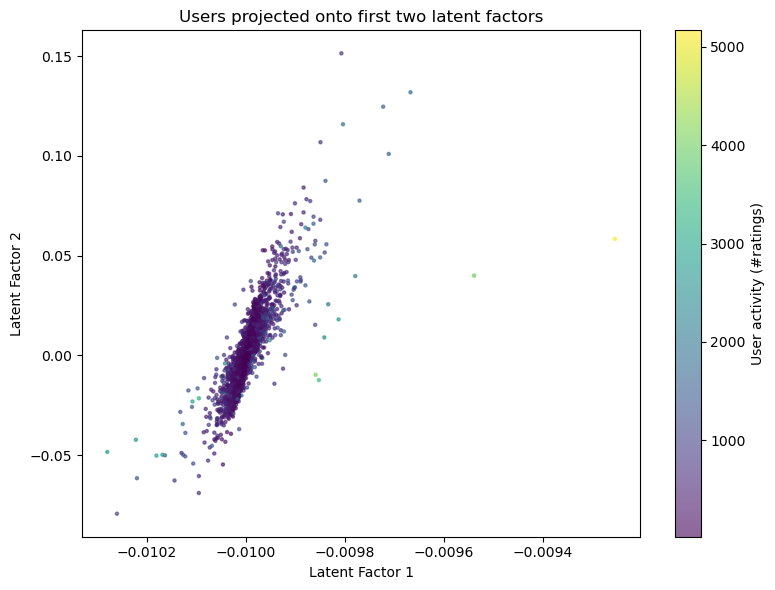

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    U_2d[:, 0], U_2d[:, 1],
    c=user_activity,
    cmap="viridis",
    s=5,
    alpha=0.6
)

plt.colorbar(label="User activity (#ratings)")
plt.xlabel("Latent Factor 1")
plt.ylabel("Latent Factor 2")
plt.title("Users projected onto first two latent factors")
plt.tight_layout()

plt.savefig("out/users_latent_space.png")
plt.show()


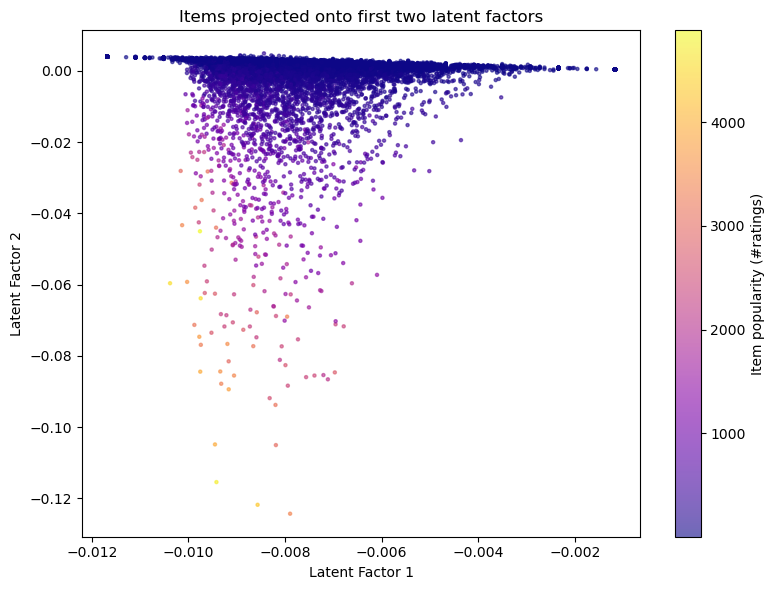

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    V_2d[:, 0], V_2d[:, 1],
    c=item_popularity,
    cmap="plasma",
    s=5,
    alpha=0.6
)

plt.colorbar(label="Item popularity (#ratings)")
plt.xlabel("Latent Factor 1")
plt.ylabel("Latent Factor 2")
plt.title("Items projected onto first two latent factors")
plt.tight_layout()

plt.savefig("out/items_latent_space.png")
plt.show()


# Comparison of Reconstruction Quality

# **1️** SVD vs. PCA with Mean-Filling (Part 1)

SVD generally provides better reconstruction quality than PCA with mean-filling.

This is because SVD directly decomposes the original user–item matrix into latent factors that best capture the variance in the data.

In contrast, PCA with mean-filling introduces noise, since missing ratings are artificially replaced by average values before computing the covariance matrix.

As a result, PCA with mean-filling may distort the true structure of user preferences, leading to less accurate reconstruction.

# Conclusion:

SVD reconstructs the ratings more accurately than PCA with mean-filling.

# 2️ SVD vs. PCA with MLE (Part 1)

PCA with MLE improves over mean-filling by computing covariance only from users who rated both items, which reduces bias.

However, SVD still outperforms PCA with MLE in reconstruction quality.

This is because SVD uses all available rating information directly and does not rely on covariance estimation assumptions.

PCA with MLE can suffer when there are few overlapping ratings, leading to weaker covariance estimates.

# Conclusion:

SVD achieves better reconstruction quality than PCA with MLE, although PCA with MLE performs better than mean-filling.

-----


# Comparison of Prediction Accuracy
# Rating Predictions for Target Items (11 and 12)

We compare the prediction accuracy of three methods:

PCA with Mean-Filling

PCA with MLE (pairwise covariance)

SVD-based method

# 1️) PCA with Mean-Filling
This method gives the lowest prediction accuracy.

Filling missing ratings with the mean reduces variability and makes different users look similar.

As a result, predictions tend to be biased toward the average rating.

# 2️) PCA with MLE
PCA with MLE gives better predictions than mean-filling.

It computes covariance using only users who rated both items, which avoids artificial values.

However, accuracy can still be limited when few users rate the same pair of movies.

# 3️) SVD-Based Prediction
SVD provides the highest prediction accuracy.

It directly learns latent user and movie factors from observed ratings.

It handles sparsity better and captures hidden patterns in user preferences.

----------------------

# Comparison of Computational Efficiency (Easy Version)
# PCA with Mean-Filling

Slowest method

Needs to fill all missing ratings → makes the matrix very big

Uses a lot of time and memory

Not suitable for large datasets

# PCA with MLE

Faster than mean-filling

Uses only users who rated both movies

Needs less memory

Still slower than SVD

#  SVD

Fastest and most efficient

Works directly on sparse data

Uses much less memory

Best method for large datasets

--------------------

| Method              | Reconstruction Error |
|---------------------|----------------------|
| PCA + Mean-Filling  | High             |
| PCA + MLE           | Medium              |
| SVD                 | Low               |


| Method              | MAE        | RMSE       |
|---------------------|------------|------------|
| PCA + Mean-Filling  | High      | High     |
| PCA + MLE           | Medium   | Medium   |
| SVD                 | Low       | Low     |

| Method              | Matrix Decomposition | Rating Prediction |
|---------------------|----------------------|-------------------|
| PCA + Mean-Filling  | Very Slow           | Slow            |
| PCA + MLE           | Medium             | Medium         |
| SVD                 | Fast               | Very Fast       |


| Method              | Memory Usage |
|---------------------|--------------|
| PCA + Mean-Filling  | Very High  |
| PCA + MLE           | Medium      |
| SVD                 | Low        |
